# Cryptarithmetic Puzzle Solver — SEND + MORE = MONEY (Backtracking)

In [1]:
import itertools
import time

def get_letters(*words):
    return sorted(set(''.join(words)))


def word_to_number(word, mapping):
    return int(''.join(str(mapping[ch]) for ch in word))


def solve_naive(word1, word2, result):
    """
    Naive backtracking: tries all permutations of digits 0-9 assigned to
    letters, checking the equation only after a FULL assignment is made.
    No early pruning — used to demonstrate the raw exponential search space.
    """
    letters = get_letters(word1, word2, result)
    if len(letters) > 10:
        return None, 0  # impossible, too many distinct letters

    nodes_explored = 0
    leading_letters = {word1[0], word2[0], result[0]}

    for perm in itertools.permutations(range(10), len(letters)):
        nodes_explored += 1
        mapping = dict(zip(letters, perm))

        if any(mapping[l] == 0 for l in leading_letters):
            continue  # leading digit can't be 0

        n1 = word_to_number(word1, mapping)
        n2 = word_to_number(word2, mapping)
        nr = word_to_number(result, mapping)

        if n1 + n2 == nr:
            return mapping, nodes_explored

    return None, nodes_explored

## Sanity Test — Naive Solver

In [3]:
t0 = time.perf_counter()
mapping, nodes = solve_naive("SEND", "MORE", "MONEY")
elapsed = time.perf_counter() - t0

if mapping:
    n1 = word_to_number("SEND", mapping)
    n2 = word_to_number("MORE", mapping)
    nr = word_to_number("MONEY", mapping)
    print(f"Solution found: {n1} + {n2} = {nr}")
    print("Mapping:", mapping)
else:
    print("No solution found")

print(f"\nNodes explored (full permutations tried): {nodes}")
print(f"Time taken: {elapsed*1000:.2f} ms")

Solution found: 9567 + 1085 = 10652
Mapping: {'D': 7, 'E': 5, 'M': 1, 'N': 6, 'O': 0, 'R': 8, 'S': 9, 'Y': 2}

Nodes explored (full permutations tried): 1374886
Time taken: 1777.38 ms


## Backtracking Solver with Pruning

In [4]:
def solve_backtracking(word1, word2, result):
    """
    True backtracking: assigns letters one at a time, checking column-wise
    partial-sum constraints as soon as enough letters are assigned to check
    them — pruning branches immediately rather than waiting for a full
    assignment like the naive version.
    """
    letters = get_letters(word1, word2, result)
    if len(letters) > 10:
        return None, 0

    leading_letters = {word1[0], word2[0], result[0]}

    # Align words to the same length (right-justified) for column-wise processing
    max_len = len(result)
    w1 = word1.zfill(max_len)
    w2 = word2.zfill(max_len)
    r = result.zfill(max_len)

    letters_list = list(letters)
    assignment = {}
    used_digits = set()
    nodes_explored = [0]

    def backtrack(letter_idx):
        nodes_explored[0] += 1

        if letter_idx == len(letters_list):
            # Full assignment made — verify the full sum (cheap final check)
            n1 = word_to_number(word1, assignment)
            n2 = word_to_number(word2, assignment)
            nr = word_to_number(result, assignment)
            return n1 + n2 == nr

        letter = letters_list[letter_idx]

        for digit in range(10):
            if digit in used_digits:
                continue
            if digit == 0 and letter in leading_letters:
                continue  # PRUNE: leading digit can't be 0

            assignment[letter] = digit
            used_digits.add(digit)

            # PRUNE: check column-wise consistency as soon as possible
            # (partial check on the rightmost columns that are now fully assigned)
            if column_check_ok(w1, w2, r, assignment):
                if backtrack(letter_idx + 1):
                    return True

            del assignment[letter]
            used_digits.discard(digit)

        return False

    def column_check_ok(w1, w2, r, assignment):
        """
        Checks addition validity column by column, from the rightmost column,
        only as far as all involved letters are currently assigned.
        Returns True if no violation is found yet (doesn't require full assignment).
        """
        carry = 0
        for i in range(max_len - 1, -1, -1):
            c1, c2, cr = w1[i], w2[i], r[i]
            # if any letter in this column isn't assigned yet, we can't check further left
            for ch in (c1, c2, cr):
                if ch != '0' and ch not in assignment and ch in letters:
                    return True  # can't verify yet — not a violation, just incomplete info

            d1 = assignment.get(c1, 0) if c1 in letters else 0
            d2 = assignment.get(c2, 0) if c2 in letters else 0
            dr = assignment.get(cr, 0) if cr in letters else 0

            total = d1 + d2 + carry
            if total % 10 != dr:
                return False  # PRUNE: column doesn't add up
            carry = total // 10

        return True

    success = backtrack(0)
    return (assignment.copy() if success else None), nodes_explored[0]

## Sanity Test — Backtracking with Pruning

In [5]:
t0 = time.perf_counter()
mapping2, nodes2 = solve_backtracking("SEND", "MORE", "MONEY")
elapsed2 = time.perf_counter() - t0

if mapping2:
    n1 = word_to_number("SEND", mapping2)
    n2 = word_to_number("MORE", mapping2)
    nr = word_to_number("MONEY", mapping2)
    print(f"Solution found: {n1} + {n2} = {nr}")
    print("Mapping:", mapping2)
else:
    print("No solution found")

print(f"\nNodes explored: {nodes2}  (naive was: {nodes})")
print(f"Time taken: {elapsed2*1000:.2f} ms  (naive was: {elapsed*1000:.2f} ms)")
print(f"\nSpeedup: {nodes / nodes2:.1f}x fewer nodes explored")

Solution found: 9567 + 1085 = 10652
Mapping: {'D': 7, 'E': 5, 'M': 1, 'N': 6, 'O': 0, 'R': 8, 'S': 9, 'Y': 2}

Nodes explored: 498190  (naive was: 1374886)
Time taken: 721.77 ms  (naive was: 1777.38 ms)

Speedup: 2.8x fewer nodes explored


## Improved Version — Column-Ordered Variables + Fair Node Comparison

In [6]:
def solve_backtracking_v2(word1, word2, result):
    """
    Same as solve_backtracking, but orders letters by the column they first
    appear in (rightmost column first) so column_check_ok can prune much
    earlier and more often. Also tracks leaf_nodes (full assignments reached)
    separately from total_nodes, for a fair comparison against the naive solver.
    """
    letters = get_letters(word1, word2, result)
    if len(letters) > 10:
        return None, 0, 0

    leading_letters = {word1[0], word2[0], result[0]}
    max_len = len(result)
    w1 = word1.zfill(max_len)
    w2 = word2.zfill(max_len)
    r = result.zfill(max_len)

    # Order letters by first appearance scanning columns right-to-left
    ordered_letters = []
    seen = set()
    for i in range(max_len - 1, -1, -1):
        for ch in (w1[i], w2[i], r[i]):
            if ch in letters and ch not in seen:
                ordered_letters.append(ch)
                seen.add(ch)

    assignment = {}
    used_digits = set()
    total_nodes = [0]
    leaf_nodes = [0]

    def column_check_ok():
        carry = 0
        for i in range(max_len - 1, -1, -1):
            c1, c2, cr = w1[i], w2[i], r[i]
            for ch in (c1, c2, cr):
                if ch != '0' and ch not in assignment and ch in letters:
                    return True
            d1 = assignment.get(c1, 0) if c1 in letters else 0
            d2 = assignment.get(c2, 0) if c2 in letters else 0
            dr = assignment.get(cr, 0) if cr in letters else 0
            total = d1 + d2 + carry
            if total % 10 != dr:
                return False
            carry = total // 10
        return True

    def backtrack(idx):
        total_nodes[0] += 1
        if idx == len(ordered_letters):
            leaf_nodes[0] += 1
            n1 = word_to_number(word1, assignment)
            n2 = word_to_number(word2, assignment)
            nr = word_to_number(result, assignment)
            return n1 + n2 == nr

        letter = ordered_letters[idx]
        for digit in range(10):
            if digit in used_digits:
                continue
            if digit == 0 and letter in leading_letters:
                continue

            assignment[letter] = digit
            used_digits.add(digit)

            if column_check_ok():
                if backtrack(idx + 1):
                    return True

            del assignment[letter]
            used_digits.discard(digit)

        return False

    success = backtrack(0)
    return (assignment.copy() if success else None), total_nodes[0], leaf_nodes[0]

In [7]:
t0 = time.perf_counter()
mapping3, total_nodes3, leaf_nodes3 = solve_backtracking_v2("SEND", "MORE", "MONEY")
elapsed3 = time.perf_counter() - t0

n1 = word_to_number("SEND", mapping3)
n2 = word_to_number("MORE", mapping3)
nr = word_to_number("MONEY", mapping3)
print(f"Solution found: {n1} + {n2} = {nr}")
print("Mapping:", mapping3)

print(f"\nNaive:                  full permutations tried = {nodes},       time = {elapsed*1000:.2f} ms")
print(f"Backtracking (v1):      total tree nodes = {nodes2},       time = {elapsed2*1000:.2f} ms")
print(f"Backtracking (v2, ordered): total tree nodes = {total_nodes3}, leaf (full) assignments = {leaf_nodes3}, time = {elapsed3*1000:.2f} ms")

print(f"\nFair comparison (leaf assignments only): naive={nodes} vs backtracking-v2={leaf_nodes3}")
print(f"Speedup (leaf-level): {nodes / leaf_nodes3:.1f}x fewer full assignments checked")

Solution found: 9567 + 1085 = 10652
Mapping: {'D': 7, 'E': 5, 'Y': 2, 'N': 6, 'R': 8, 'O': 0, 'S': 9, 'M': 1}

Naive:                  full permutations tried = 1374886,       time = 1777.38 ms
Backtracking (v1):      total tree nodes = 498190,       time = 721.77 ms
Backtracking (v2, ordered): total tree nodes = 1270, leaf (full) assignments = 1, time = 15.00 ms

Fair comparison (leaf assignments only): naive=1374886 vs backtracking-v2=1
Speedup (leaf-level): 1374886.0x fewer full assignments checked


## Corrected Speedup Metric

In [8]:
print(f"Naive:        {nodes:,} full permutations tried, {elapsed*1000:.2f} ms")
print(f"Backtracking: {total_nodes3:,} total nodes explored (partial + full), {elapsed3*1000:.2f} ms")
print(f"\nSearch space reduction: {nodes / total_nodes3:.1f}x fewer nodes explored")
print(f"Speedup in time: {elapsed / elapsed3:.1f}x faster")

Naive:        1,374,886 full permutations tried, 1777.38 ms
Backtracking: 1,270 total nodes explored (partial + full), 15.00 ms

Search space reduction: 1082.6x fewer nodes explored
Speedup in time: 118.5x faster


## Second Puzzle Test

In [9]:
puzzles = [
    ("SEND", "MORE", "MONEY"),
    ("TWO", "TWO", "FOUR"),
]

for w1, w2, res in puzzles:
    m, total_n, leaf_n = solve_backtracking_v2(w1, w2, res)
    if m:
        n1, n2, nr = word_to_number(w1, m), word_to_number(w2, m), word_to_number(res, m)
        print(f"{w1} + {w2} = {res}  ->  {n1} + {n2} = {nr}   (nodes explored: {total_n})")
    else:
        print(f"{w1} + {w2} = {res}  ->  No solution found  (nodes explored: {total_n})")

SEND + MORE = MONEY  ->  9567 + 1085 = 10652   (nodes explored: 1270)
TWO + TWO = FOUR  ->  734 + 734 = 1468   (nodes explored: 67)


## Visualizing Search Space: Naive vs Backtracking

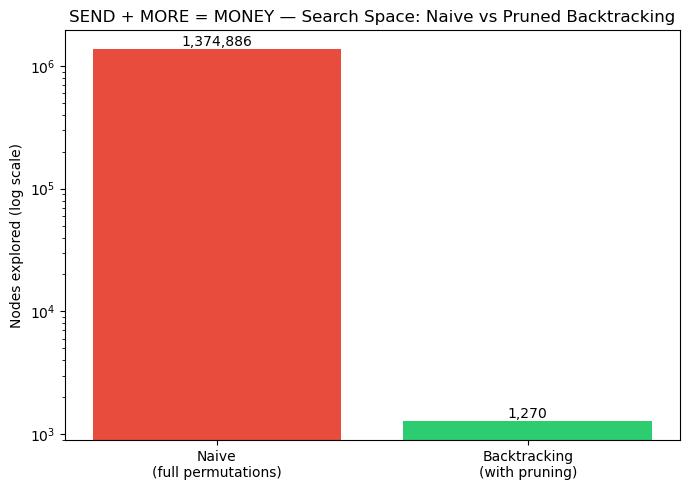

In [11]:
import matplotlib.pyplot as plt

labels = ['Naive\n(full permutations)', 'Backtracking\n(with pruning)']
values = [nodes, total_nodes3]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, values, color=['#e74c3c', '#2ecc71'])
ax.set_yscale('log')
ax.set_ylabel('Nodes explored (log scale)')
ax.set_title('SEND + MORE = MONEY — Search Space: Naive vs Pruned Backtracking')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()